<a href="https://colab.research.google.com/github/krishnakanth-20/Covid_Prediction/blob/main/Hands_on_minst__dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><font size = 8> Classification Model for Handwritten Digits (0-9) </center></font>
<center><font size = 6> MNIST dataset
</center></font>

<center>
  <img src="https://drive.google.com/uc?export=view&id=1CAIHWx28g2INTpV00raVPYThw4Y2cTJg" alt="Description">
</center>

# Data Description

## overview of the notebook's content:

* **Objective**: Handwritten digit classification(0-9).

* **Dataset:** MNIST dataset.

* **Problem Type:** Multi-class classification.

* **Data Size:**
    
      `60,000` training images (28x28 pixels).
      `10,000` test images (28x28 pixels).

* **Models Used:**

    * Baseline model (no hidden layers).

    *  Models with one or more dense hidden layers (64, 128, 32 neurons).

    *  Exploration of activation functions: Sigmoid, Tanh, ReLU.

    *  Exploration of effect of batch size and epoches: batch sizes (32,64,50000) epoches (5,10,50,100).

* **Workflow Overview:**
  * **Data Loading:** Loaded MNIST from `tensorflow.keras.datasets.mnist.load_data()`

  * **Data Overview:** Visualized sample images and class distributions.

  * **Data Preprocessing:**
    
    Split training data into `train/validation`,
    
    scaled pixel values to `[0,255] --> [0,1]`,
    
    reshaped images to `28 x 28 (n, 784)`, and
    
    `one-hot encoded` target labels (0 -9 labels).

  * **Model Building & Evaluation:** Iteratively built and evaluated multiple sequential models,  experimenting with:
    
    * Number of epochs (10, 50, 100).
    * Batch size (full batch, 32, 64).
    * Number of hidden layers (0, 1, 2, 3).
    * Number of neurons per hidden layer (64, 128, 32).
    * Activation functions (sigmoid, tanh, relu, softmax).

* **Conclusions:** Analyzed the impact of different hyperparameters on model performance (accuracy and loss) and training time

The **MNIST** (Modified National Institute of Standards and Technology) dataset is a widely used **benchmark in machine learning** for `handwritten digit` recognition, consisting of

* `70,000` grayscale images of digits `0–9`.

* Each image is a `28x28 pixel square`,  Each image is of `28x28 dimension = 784` size-normalized and centered, with pixel intensities ranging from
`0 (black) to 255 (white)`.

The dataset is **pre-split** into a

    > training set of 60,000 images
    > test set of 10,000 images,
    
   ensuring a balanced distribution across all 10 digit classes.  It was created by Yann LeCun, Corinna Cortes, and Christopher J.C. Burges from subsets of NIST’s Special Database 1 and 3.



# Installing and importing the necessary libraries

In [2]:
# Installing the libraries with the specified version
!pip install --no-deps --force-reinstall tensorflow==2.18.0 scikit-learn==1.3.2 matplotlib===3.8.3 seaborn==0.13.2 numpy==1.26.4 pandas==2.2.2 --no-deps --force-reinstall -q --user --no-warn-script-location

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.5/615.5 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 89.0 MB/s eta 0:00:00


In [3]:
import pandas as pd  # Library for data manipulation and analysis.
import numpy as np   # Fundamental package for scientific computing.
import matplotlib.pyplot as plt  # Plotting library for creating visualizations.
import seaborn as sns #For advanced visualizations.

from sklearn.model_selection import train_test_split  # Function for splitting datasets for training and testing.

import time  # Module for time-related operations.

import tensorflow as tf #An end-to-end open source machine learning platform
from tensorflow import keras  # High-level neural networks API for deep learning and MINST datset.

from keras import backend   # Abstraction layer for neural network backend engines.
from keras.models import Sequential  # Model for building NN sequentially.
from keras.layers import Dense   # for creating fully connected neural network layers.

In [4]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
keras.utils.set_random_seed(812)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it might affect the overall performance
tf.config.experimental.enable_op_determinism()

## Loading the data

In [5]:
#Loading the dataset from tensorflow datasets.
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


train-images-idx3-ubyte.gz: training set images (9912422 bytes) (60000)

train-labels-idx1-ubyte.gz: training set labels (28881 bytes) (60000)

t10k-images-idx3-ubyte.gz: test set images (1648877 bytes) (10000)

t10k-labels-idx1-ubyte.gz: test set labels (4542 bytes) (10000)

# Data Overview

In [ ]:
#Printing the shape of the data.
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [6]:
np.set_printoptions(linewidth=500)

print(x_train[1])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  51 159 253 159  50   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  48 238 252 252 252 237   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  54 227 253 252 239 233 252  57   6   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  10  60 224 252 253 252 202  84 252 253 122   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 163 252 252 252 253 252 252  96 18

28 x 28 = 784

**Let's check the images for different digits.**

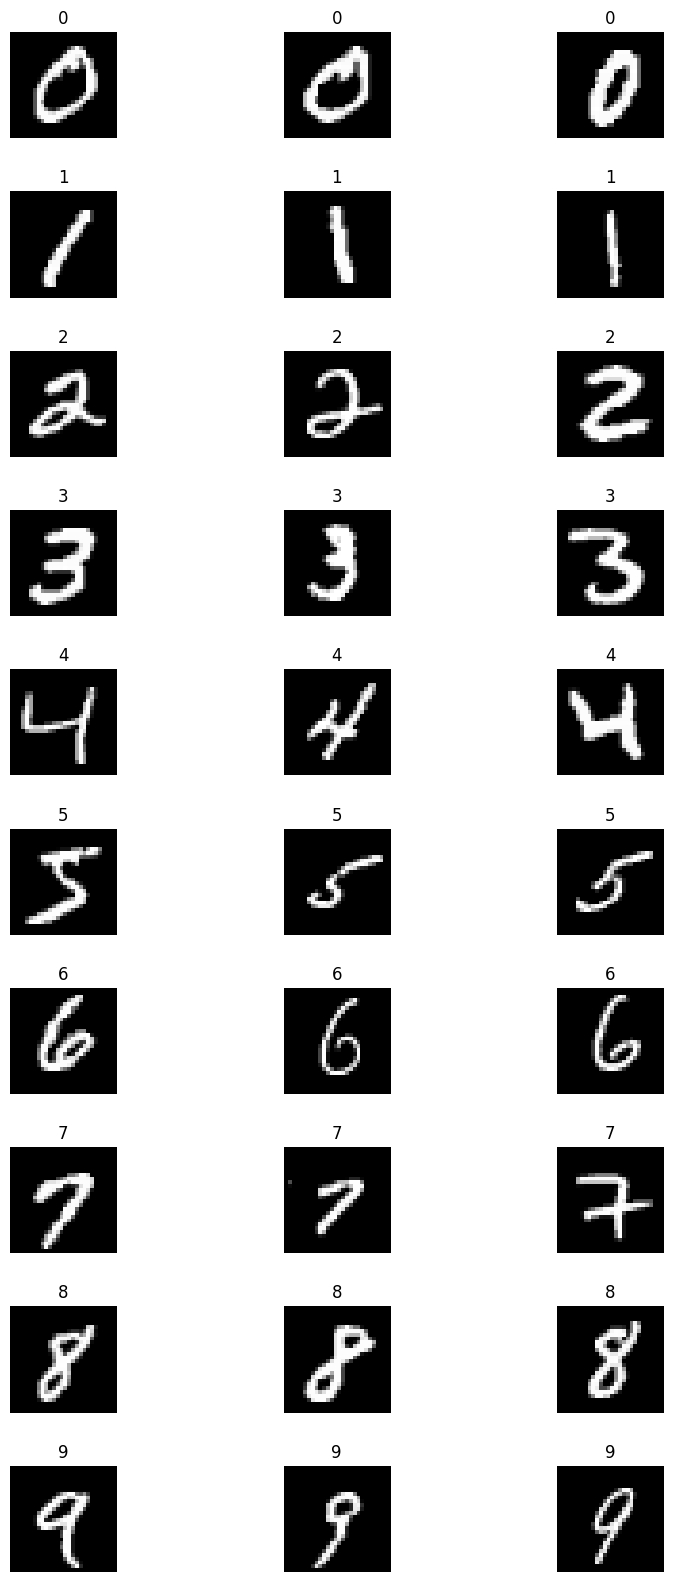

In [7]:
f, axarr = plt.subplots(10,3,figsize=(10, 20)) #Grid of size 10*20, with 10 rows and 2 columns
for i in range(10): #For each digit
    images = x_train[y_train==i] #Filtering all the images based on the digit.
    axarr[i,0].imshow(images[0],cmap="gray") #Plotting the first one.
    axarr[i,1].imshow(images[1],cmap="gray") #Plotting the second one.
    axarr[i,2].imshow(images[2],cmap="gray")
    axarr[i,0].axis('off')  # Hide axes
    axarr[i,1].axis('off')  # Hide axes
    axarr[i,2].axis('off')
    axarr[i,0].set_title(str(i)) #Setting the title as the label of the digit.
    axarr[i,1].set_title(str(i)) #Setting the title as the label of the digit.
    axarr[i,2].set_title(str(i))

plt.subplots_adjust(hspace=0.5)  # Adjust spacing between subplots
plt.show() #Displaying the plot.

On observing the data for same numbers are different for training to understand any handwritting

**Let's check the distribution of images across different classes.**

### distribution for Train data

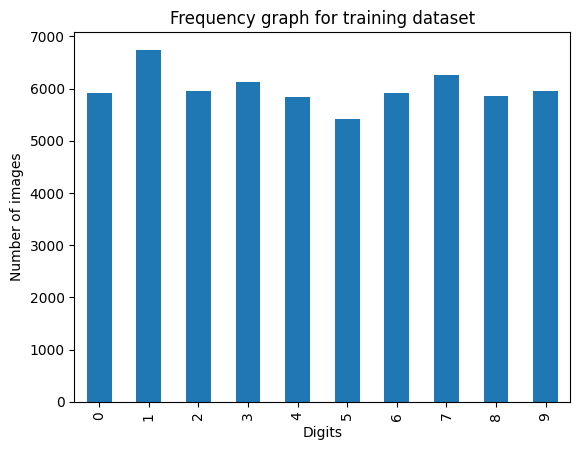

In [8]:
# frequency plot of the dependent variable in the training dataset
(pd.Series(y_train).value_counts())[[0,1,2,3,4,5,6,7,8,9]].plot.bar()
plt.title("Frequency graph for training dataset") #Setting the title
plt.xlabel("Digits") #Defining the label for the x-axis
plt.ylabel("Number of images") #Defining the label for the y-axis.
plt.show() #Displaying the plot.

### For Test Data

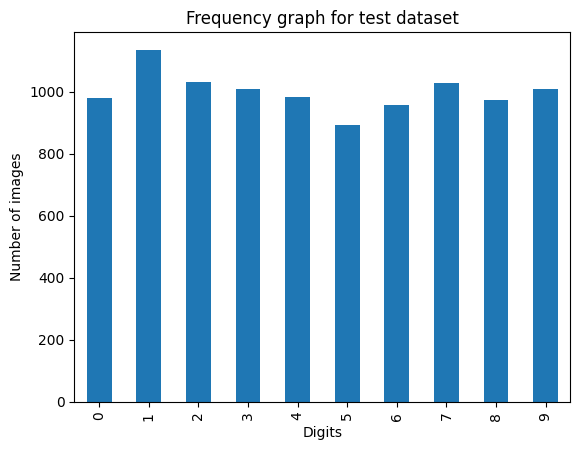

In [9]:
# frequency plot of the dependent variable in the test dataset
(pd.Series(y_test).value_counts())[[0,1,2,3,4,5,6,7,8,9]].plot.bar()
plt.title("Frequency graph for test dataset") #Setting the title
plt.xlabel("Digits") #Defining the label for the x-axis
plt.ylabel("Number of images") #Defining the label for the y-axis.
plt.show() #Displaying the plot.

# Data Preprocessing

### Data Preparation for Modeling

In [10]:
# Splitting the training dataset in the ratio 5:1 for train and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=1-(5/6), random_state=42,stratify=y_train)

### Split validation from Train data
  test_size=1-(5/6)  --->  
      
      simplifies to `1/6`,
      meaning `1/6th` (or approximately 16.67%)
      of the x_train and y_train data will be used for validation, and the remaining `5/6th` will be used for training.

  random_state=42  --->
  
    the data split is always the same every time you run the code.

  stratify=y_train  --->

    This parameter is used for stratified sampling.

    the proportion of classes in the y_train (target variable) is maintained in both the training and validation sets.





### Data Scaling

### Normalization

In [11]:
#Printing the maximum value and the minimum value of the independent variable.
print(x_train.max(),x_test.max(),x_val.max())
print(x_train.min(),x_test.min(),x_val.min())

255 255 255
0 0 0


In [13]:
# Normalizing the dataset
x_train, x_val, x_test = x_train.astype("float32")/(255), x_val.astype("float32")/(255), x_test.astype("float32")/(255)

In [14]:
#Printing the maximum value and the minimum value of the independent variable.
print(x_train.max(),x_test.max(),x_val.max())
print(x_train.min(),x_test.min(),x_val.min())

1.0 1.0 1.0
0.0 0.0 0.0


- Previously, the range was $[0,255]$
- Now, the range after normalizing is $[0,1]$

### Reshaping the input

operation flattens each 2D image into a 1D vector

We need to reshape the image data from $(n,h,w)$ to $(n,h*w)$, where

- $n$ = number of images in the dataset
- $h$ = height of the image
- $w$ = width of the image

For example, image data of dimension $(50000,28,28)$ is transformed to $(50000,28*28)$, i.e., $(50000,784)$.

In [ ]:
#Reshaping the image data
x_train = x_train.reshape(x_train.shape[0],-1) #(50000,28 x 28)
x_val = x_val.reshape(x_val.shape[0],-1)
x_test = x_test.reshape(x_test.shape[0],-1)

In [ ]:
print(x_train.shape[0], "train samples")
print(x_val.shape[0], "validation samples")
print(x_test.shape[0], "test samples")

50000 train samples
10000 validation samples
10000 test samples


In [ ]:
x_train.shape

(50000, 784)

### Encoding the target variable

### classes =  (0 - 9)
### most opted function softmax

In [ ]:
# specifying the number of classes
num_classes = 10

Target Encoding - one hot encoding (y)

In [ ]:
# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)

In [ ]:
#Displaying the updated class labels
y_train

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])

In [ ]:
y_train.shape

(50000, 10)

- Each row in the matrix is now a one-hot encoded vector of 10 dimensions
- The value will be 1 for the entry (dimension) corresponding true class and 0 elsewhere

### Utility functions

In [ ]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

We'll create a dataframe to store the results from all the models we build

metrical evaluation

In [ ]:
#Defining the columns of the dataframe which are nothing but the hyper parameters and the metrics.
columns = ["# hidden layers","# neurons - hidden layer","activation function - hidden layer","# epochs","batch size","train loss","validation loss","train accuracy","validation accuracy","time (secs)"]

#Creating a pandas dataframe.
results = pd.DataFrame(columns=columns)

# Model Building

## Model 0

**baseline model** having an
      
    ✅ input layer, - 784 dim
    ✅ an output layer, - 10 class
    ❌ no hidden layers.

-  optimizer - Strocastic Gradient Descent .
-  epochs - 10
-  activation - softmax

 which means the model will pass over the entire data 10 times


<center>
  <img src="https://drive.google.com/uc?export=view&id=1KhuLQG92xx7w2prc7EkS6mLkpAuh0eTT" alt="Description">
</center>


In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
# initializing the neural network
model = Sequential()

# Adding a dense layer with softmax activation function, with the input dimension determined by the shape of the training data. 784
model.add(Dense(num_classes, activation = 'softmax', input_dim = x_train.shape[1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Let's go over the arguments of the function used above:

- `num_classes`:  Positive integer, dimensionality of the output vector. In this case, it is 10.

- `activation`: Activation function to use. If nothing is specified, no activation is applied (i.e., "linear" activation: $a(x) = x$).

- `input_dim`: Positive integer, dimensionality of the input vector. In this case, it is 784.

**Note**: We do not have to explicitly add an input layer. Once we initialize a neural network using `Sequential()`, it automatically assigns a default input layer. We just define an output layer and connect it to the predefined input layer.

In [ ]:
#Printing the summary.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Compiling the model.
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [ ]:
batch_size = x_train.shape[0] # 50,000
epochs = 10

# time.time() returns the time in seconds since Thu Jan 1 00:00:00 1970.
start = time.time()

# Fitting the model.
history = model.fit(
    x_train, y_train,
    validation_data=(x_val,y_val),
    batch_size=batch_size,
    epochs=epochs
)

# time.time() returns the time in seconds since Thu Jan 1 00:00:00 1970.
end = time.time()

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0933 - loss: 2.3785 - val_accuracy: 0.1019 - val_loss: 2.3576
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.0996 - loss: 2.3633 - val_accuracy: 0.1081 - val_loss: 2.3429
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 637ms/step - accuracy: 0.1053 - loss: 2.3485 - val_accuracy: 0.1159 - val_loss: 2.3286
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 766ms/step - accuracy: 0.1115 - loss: 2.3342 - val_accuracy: 0.1224 - val_loss: 2.3148
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 778ms/step - accuracy: 0.1180 - loss: 2.3203 - val_accuracy: 0.1286 - val_loss: 2.3014
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1244 - loss: 2.3068 - val_accuracy: 0.1342 - val_loss: 2.2882
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 818ms/step - accuracy: 0.1313 - loss: 2.2936 - val_accuracy: 0.1408 - val_loss: 2.2755
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1380 - loss: 2.2807 - val_accuracy: 0.1480 - val_loss: 2.2630
E

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  11.616696834564209


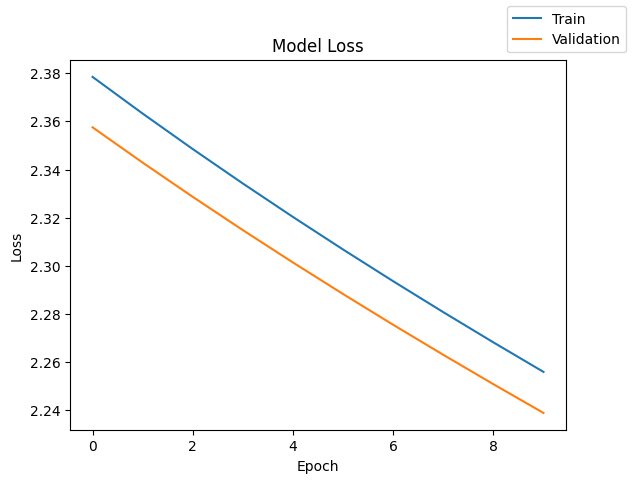

In [ ]:
plot(history,'loss')

- Both train and validation loss are decreasing linearly.

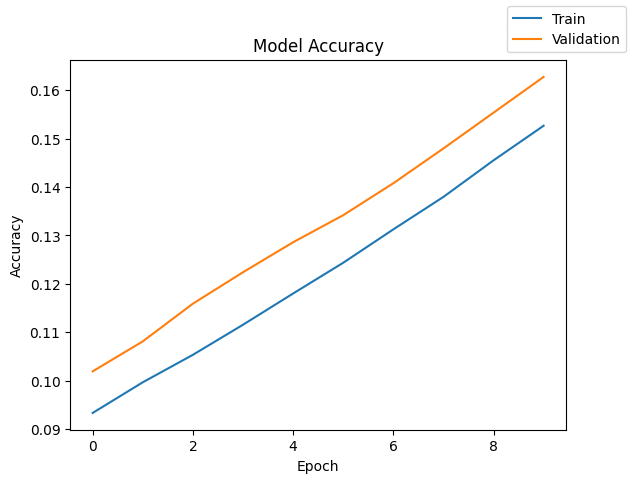

In [ ]:
plot(history,'accuracy')

- As accuracy is inversely proportional to the loss, the graph is linearly increasing.

In [ ]:
results.loc[0] = [0,'-','-',10,50000,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,train loss,validation loss,train accuracy,validation accuracy,time (secs)
0,0,-,-,10,50000,2.255868,2.238811,0.1527,0.1628,11.62


- With the baseline model and 10 epochs, we were able to obtain an accuracy of ~15%, which is very low

- ***How do we improve the performance?***

- We can allow the model to **run over the data more times**. This can be done by **increasing the number of epochs**.

- Let's try this out.

###Model 1

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(num_classes, activation = 'softmax', input_dim = x_train.shape[1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = x_train.shape[0]
epochs = 50
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [ ]:
start = time.time()
history = model.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.0724 - loss: 2.4184 - val_accuracy: 0.0749 - val_loss: 2.4064
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.0750 - loss: 2.4036 - val_accuracy: 0.0784 - val_loss: 2.3921
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.0777 - loss: 2.3893 - val_accuracy: 0.0819 - val_loss: 2.3783
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step - accuracy: 0.0804 - loss: 2.3754 - val_accuracy: 0.0847 - val_loss: 2.3649
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.0844 - loss: 2.3619 - val_accuracy: 0.0879 - val_loss: 2.3518
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.0879 - loss: 2.3487 - val_accuracy: 0.0912 - val_loss: 2.3390
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.0916 - loss: 2.3359 - val_accuracy: 0.0951 - val_loss: 2.3265
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.0961 - loss: 2.3234 - val_accuracy: 0.1005 - val_loss: 2.

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  26.035585165023804


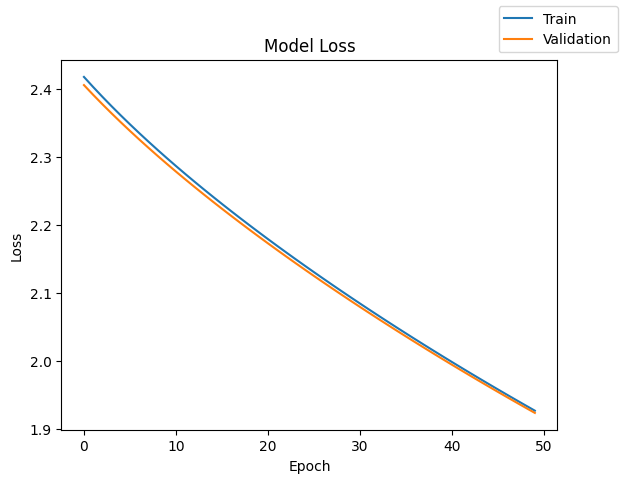

In [ ]:
plot(history,'loss')

- The apparently linear relationship between epochs and loss (as seen before) is slowly becoming non-linear now
    - We see a slight curvature in the plot here

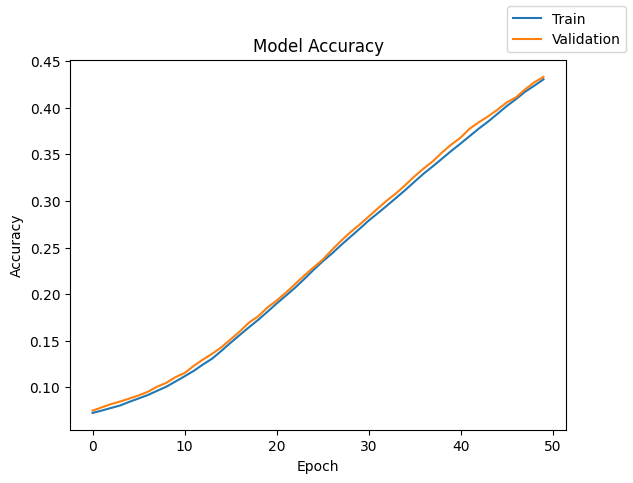

In [ ]:
plot(history,'accuracy')

- The non-linear relationship is more clearly visible here than before
- Note that the train accuracy (orange curve) remains below or equal to the validation accuracy (blue curve)

In [ ]:
results.loc[1]= [0,'-','-',50,50000,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

In [ ]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,train loss,validation loss,train accuracy,validation accuracy,time (secs)
0,0,-,-,10,50000,2.255868,2.238811,0.1527,0.1628,11.62
1,0,-,-,50,50000,1.927448,1.924149,0.4306,0.4332,26.04


- The accuracy has improved significantly compared to the previous model (~180%)
- The time taken to train has also increased.
- It is important to note that since we are using **vanilla Gradient Descent**, the **model parameters are updated once every epoch**
- We can use Stochastic Gradient Descent to update the model parameters more frequently in a single epoch
- Let's try this out



###Model 2

In [ ]:
#clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(num_classes, activation = 'softmax', input_dim = x_train.shape[1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = 32
epochs = 10
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [ ]:
start = time.time()
history = model.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8081 - loss: 0.8309 - val_accuracy: 0.8657 - val_loss: 0.5347
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8778 - loss: 0.4763 - val_accuracy: 0.8815 - val_loss: 0.4438
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8883 - loss: 0.4176 - val_accuracy: 0.8886 - val_loss: 0.4066
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8943 - loss: 0.3885 - val_accuracy: 0.8949 - val_loss: 0.3852
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8988 - loss: 0.3702 - val_accuracy: 0.8986 - val_loss: 0.3709
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9019 - loss: 0.3572 - val_accuracy: 0.9011 - val_loss: 0.3604
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9035 - loss: 0.3474 - val_accuracy: 0.9029 - val_loss: 0.3524
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9054 - loss: 0.3396 - 

- The accuracy has improved by a significant margin.
- Note that after one epoch, we got an accuracy of 80%.
    - As we updated the model parameters more frequently (50000/32 = 1563 times) in a single epoch, our model was able to adjust to the data better
    - It took the same amount of time (~4s) for one epoch here vs 10 epochs previously. But the performance gain is much higher
    - This shows that the rate of learning from the data has improved

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  59.803773403167725


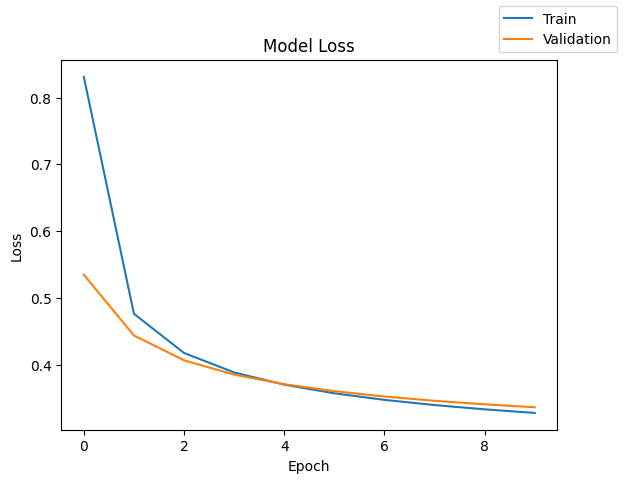

In [ ]:
plot(history,'loss')

- Until the 4th epoch, the validation loss is lesser than or equal to the train loss.

- After the 4th epoch, the validation loss is higher than the train loss.

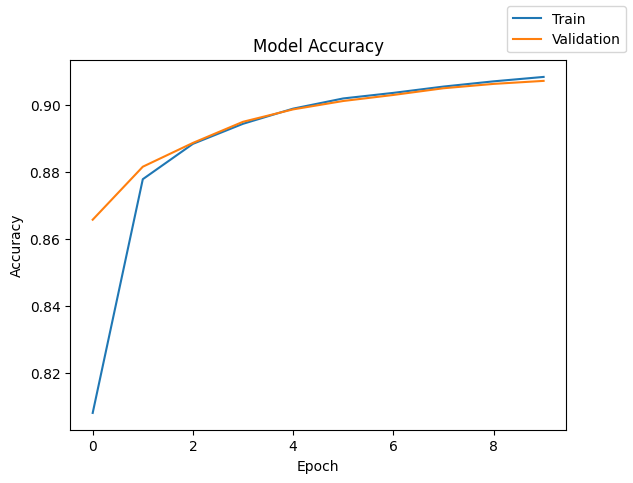

In [ ]:
plot(history,'accuracy')

- Here, after the 4th epoch, validation accuracy is lesser than or equal to the train accuracy.

**The divergence between the train and validation accuracies may hint that the model is slowly moving towards being an overfit model.**

In [ ]:
results.loc[2] = [0,'-','-',10,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

In [ ]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,train loss,validation loss,train accuracy,validation accuracy,time (secs)
0,0,-,-,10,50000,2.255868,2.238811,0.15270,0.1628,11.62
1,0,-,-,50,50000,1.927448,1.924149,0.43060,0.4332,26.04
2,0,-,-,10,32,0.327848,0.336322,0.90828,0.9071,59.80


- It is clear that using a smaller batch size improves the rate of learning.
    - We saw an ~100% improvement here

- Now, let's keep the batch size the same and increase the epochs to 50
   - We saw previously that more epochs result in more updates. So, we can expect an increase in accuracy.

###Model 3

In [ ]:
#clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(num_classes, activation = 'softmax', input_dim = x_train.shape[1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = 32
epochs = 50
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [ ]:
start = time.time()
history = model.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8067 - loss: 0.8327 - val_accuracy: 0.8658 - val_loss: 0.5356
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8776 - loss: 0.4767 - val_accuracy: 0.8823 - val_loss: 0.4446
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8884 - loss: 0.4180 - val_accuracy: 0.8904 - val_loss: 0.4070
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8944 - loss: 0.3887 - val_accuracy: 0.8953 - val_loss: 0.3853
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8983 - loss: 0.3703 - val_accuracy: 0.8997 - val_loss: 0.3708
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9016 - loss: 0.3572 - val_accuracy: 0.9017 - val_loss: 0.3603
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9042 - loss: 0.3473 - val_accuracy: 0.9034 - val_loss: 0.3522
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9057 - loss: 0.3395 - 

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  258.2361879348755


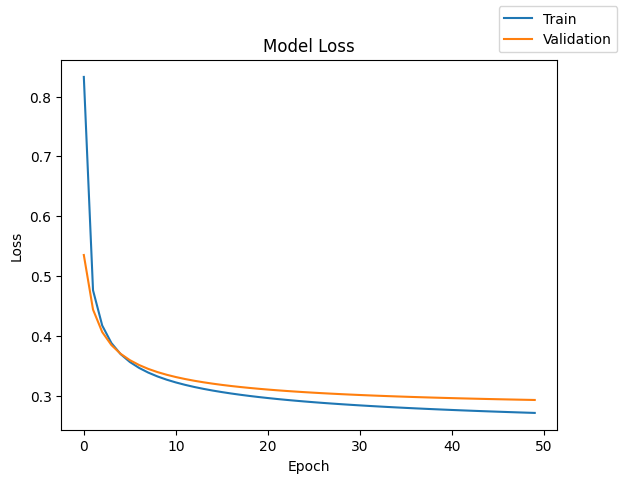

In [ ]:
plot(history,'loss')

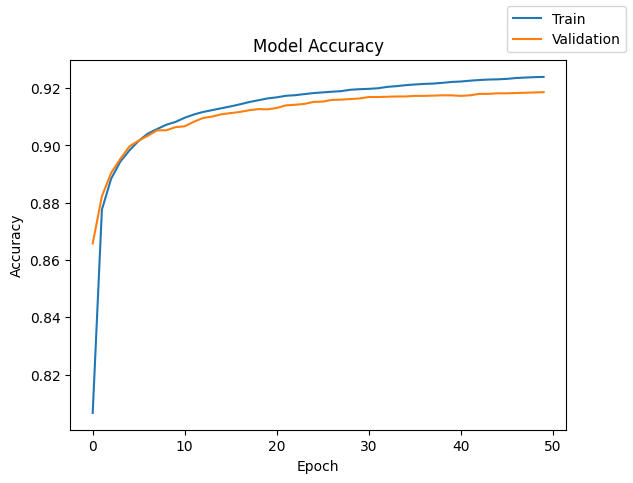

In [ ]:
plot(history,'accuracy')

- As seen previously, the train and validation losses (and accuracies) start to diverge after a few epochs
    - Here, it is ~5 epochs

- Also, after a point (somewhere between 20 and 30 epochs), the train and validation losses (and accuracies) start to plateau and show minimal change
    - This indicates that we might choose to not train the neural network beyond certain number of epochs as the performance gain might not be high

In [ ]:
results.loc[3] = [0,'-','-',50,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

In [ ]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,train loss,validation loss,train accuracy,validation accuracy,time (secs)
0,0,-,-,10,50000,2.255868,2.238811,0.15270,0.1628,11.62
1,0,-,-,50,50000,1.927448,1.924149,0.43060,0.4332,26.04
2,0,-,-,10,32,0.327848,0.336322,0.90828,0.9071,59.80
3,0,-,-,50,32,0.272220,0.293814,0.92392,0.9186,258.24


- We can see some improvement in the overall accuracy, but it's not as great an improvement as we saw previously

- In fact, we took 5 times more time for a ~2% accuracy gain

**Note**: This tradeoff may be feasible in certain cases but not in others. For example, in case of real-time predictions, one can choose to sacrifice a small performance gain for a much reduced prediction time.

- We saw that training longer doesn't really lead to a larger improvement in model performance
- Since we had a batch size of 32, the model parameters update was based on only these 32 samples
- ***What if we increase the number of samples based on which the updates are made?***
- Let's try increasing the batch size to 64.

###Model 4

In [ ]:
#clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(num_classes, activation = 'softmax', input_dim = x_train.shape[1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = 64
epochs = 50
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [ ]:
start = time.time()
history = model.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7539 - loss: 1.0613 - val_accuracy: 0.8433 - val_loss: 0.6841
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8583 - loss: 0.5916 - val_accuracy: 0.8665 - val_loss: 0.5383
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8733 - loss: 0.4997 - val_accuracy: 0.8764 - val_loss: 0.4795
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8812 - loss: 0.4553 - val_accuracy: 0.8833 - val_loss: 0.4462
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8858 - loss: 0.4278 - val_accuracy: 0.8868 - val_loss: 0.4242
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8898 - loss: 0.4088 - val_accuracy: 0.8905 - val_loss: 0.4083
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8928 - loss: 0.3945 - val_accuracy: 0.8930 - val_loss: 0.3961
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8951 - loss: 0.3833 - val_accuracy: 0.

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  171.7976291179657


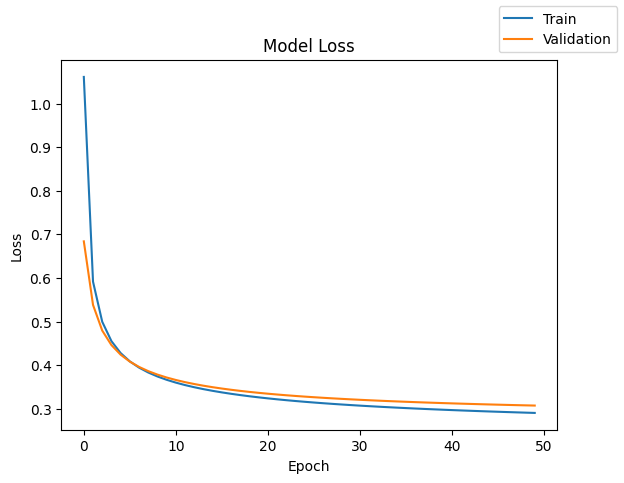

In [ ]:
plot(history,'loss')

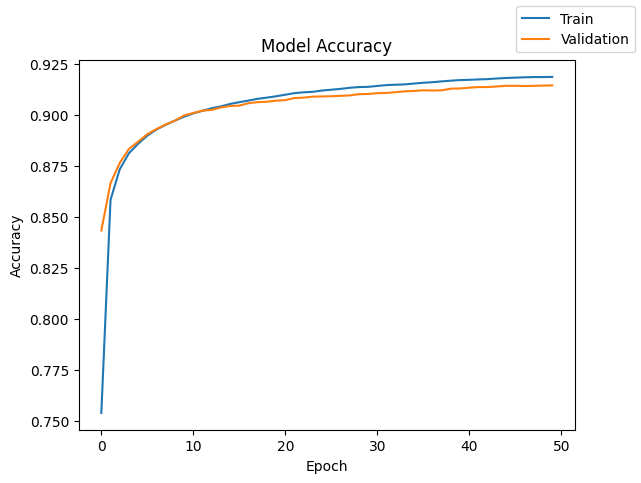

In [ ]:
plot(history,'accuracy')

In [ ]:
results.loc[4] = [0,'-','-',50,64,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

In [ ]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,train loss,validation loss,train accuracy,validation accuracy,time (secs)
0,0,-,-,10,50000,2.255868,2.238811,0.15270,0.1628,11.62
1,0,-,-,50,50000,1.927448,1.924149,0.43060,0.4332,26.04
2,0,-,-,10,32,0.327848,0.336322,0.90828,0.9071,59.80
3,0,-,-,50,32,0.272220,0.293814,0.92392,0.9186,258.24
4,0,-,-,50,64,0.290571,0.307456,0.91856,0.9144,171.80


- The time to train the model has reduced by \~50%, and there is a minimal dip in the accuracy (\~1%).

- Note that the model accuracy after one epoch is \~75% now (vs \~80% when we set batch size to 32)

- But, after 10 epochs, the model accuracy is approx. the same (\~90% for batch size 64 vs \~91% for batch size 32)
    - Perhaps there are some noisy points that don't contribute positively even after increasing the batch size for a better weight updates.

- We haven't added a hidden layer to our neural network so far

- Let's try adding a hidden layer

- Also, let's compare vanilla gradient descent and stochastic gradient descent with the updated architecture (1 input + 1 hidden + 1 output).

###Model 5


<center>
  <img src="https://drive.google.com/uc?export=view&id=1VxKjE9-J1Ky-GOLQrQHntGrxHB6IrXMf" alt="Description">
</center>


In [ ]:
#clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(64,activation='sigmoid',input_dim = x_train.shape[1]))
model.add(Dense(num_classes, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

- As the network has one hidden and one output layer, both being dense layers, the same is reflected in the model summary

- Let's understand the computation of the total number of parameters in the model
    - Each of the 784 input neurons is connected to the 64 neurons in the hidden layer
    - This gives us 784*64 = 50176 weight parameters and 64 bias parameters, totaling 50240 parameters for the connections between the input and hidden layers.
    - Each of the 64 neurons in the hidden layer is connected to the 10 neurons in the output layer.
    - This gives us 64*10 = 640 weight parameters and 10 bias parameters, totaling 650 parameters for the connections between the hidden and output layers.
    - Thus, the total number of parameters is 50240 + 650 = 50890

In [ ]:
batch_size = x_train.shape[0]
epochs = 50
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [ ]:
start = time.time()
history = model.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0939 - loss: 2.4435 - val_accuracy: 0.0954 - val_loss: 2.4353
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step - accuracy: 0.0941 - loss: 2.4358 - val_accuracy: 0.0963 - val_loss: 2.4280
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step - accuracy: 0.0941 - loss: 2.4285 - val_accuracy: 0.0965 - val_loss: 2.4210
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 825ms/step - accuracy: 0.0941 - loss: 2.4215 - val_accuracy: 0.0968 - val_loss: 2.4143
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0945 - loss: 2.4148 - val_accuracy: 0.0971 - val_loss: 2.4080
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 957ms/step - accuracy: 0.0951 - loss: 2.4085 - val_accuracy: 0.0975 - val_loss: 2.4019
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 651ms/step - accuracy: 0.0955 - loss: 2.4024 - val_accuracy: 0.0981 - val_loss: 2.3961
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step - accuracy: 0.0959 - loss: 2.3966 - val_accuracy: 0.0988 - val_loss: 2.390

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  38.20582723617554


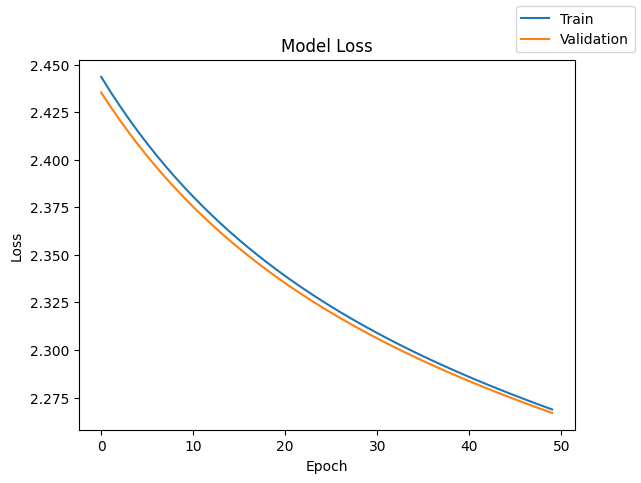

In [ ]:
plot(history,'loss')

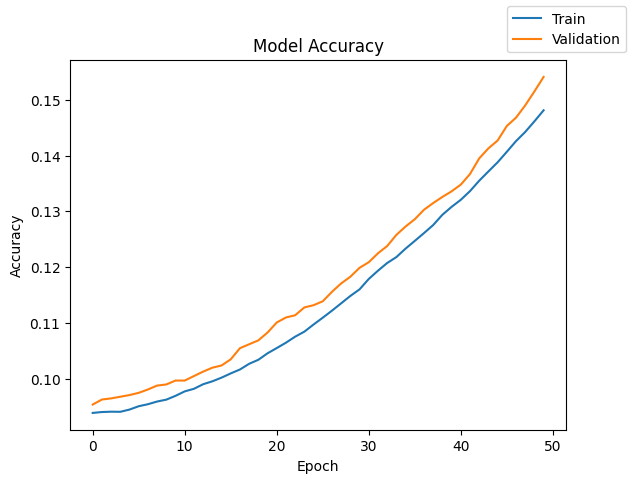

In [ ]:
plot(history,'accuracy')

- In this case, the validation loss is always lesser than the training loss.

- Consequently, the validation accuracy is always higher than the training accuracy.

In [ ]:
results.loc[5] = [1,64,'sigmoid',50,50000,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

In [ ]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,train loss,validation loss,train accuracy,validation accuracy,time (secs)
0,0,-,-,10,50000,2.255868,2.238811,0.15270,0.1628,11.62
1,0,-,-,50,50000,1.927448,1.924149,0.43060,0.4332,26.04
2,0,-,-,10,32,0.327848,0.336322,0.90828,0.9071,59.80
3,0,-,-,50,32,0.272220,0.293814,0.92392,0.9186,258.24
4,0,-,-,50,64,0.290571,0.307456,0.91856,0.9144,171.80
5,1,64,sigmoid,50,50000,2.268767,2.266936,0.14812,0.1541,38.21


- From the above results table, it's clear that the model isn't performing well
    - We got better performance with no hidden layers (index 1 vs index 5)

- It seems that just adding a hidden layer isn't improving the model performance.

- Let's check if reducing the batch size to 32 (i.e., implementing stochastic gradient descent) does a better job.

###Model 6

In [ ]:
#clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(64,activation='sigmoid',input_dim = x_train.shape[1]))
model.add(Dense(num_classes, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = 32
epochs = 50
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [ ]:
start = time.time()
history = model.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6441 - loss: 1.6074 - val_accuracy: 0.7794 - val_loss: 1.0945
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8249 - loss: 0.8611 - val_accuracy: 0.8469 - val_loss: 0.7089
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8597 - loss: 0.6221 - val_accuracy: 0.8694 - val_loss: 0.5616
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8759 - loss: 0.5167 - val_accuracy: 0.8817 - val_loss: 0.4856
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8850 - loss: 0.4576 - val_accuracy: 0.8885 - val_loss: 0.4394
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8908 - loss: 0.4196 - val_accuracy: 0.8931 - val_loss: 0.4083
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8952 - loss: 0.3929 - val_accuracy: 0.8966 - val_loss: 0.3859
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8988 - loss: 0.37

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  382.6803767681122


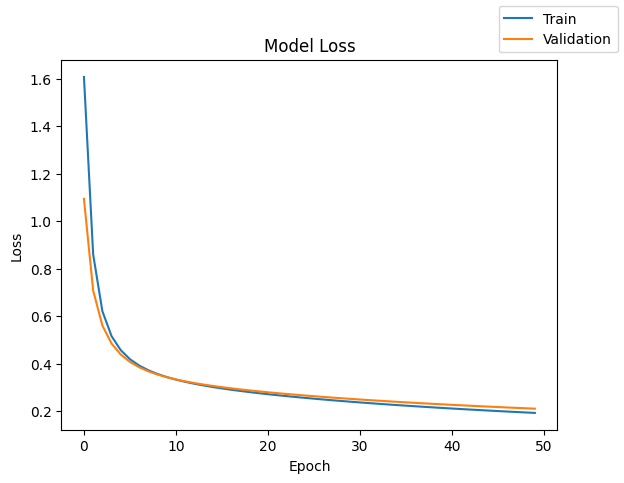

In [ ]:
plot(history,'loss')

- The train and validation loss are almost the same from the 10th epoch, and a slight divergence is observed when nearing the 45th epoch.

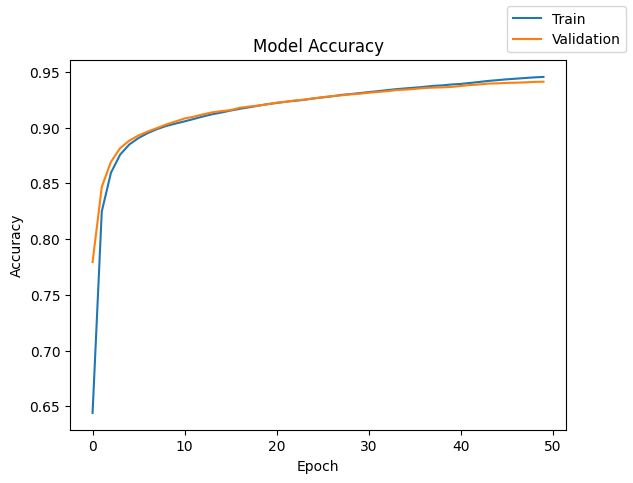

In [ ]:
plot(history,'accuracy')

- The train and validation accuracy are almost the same from the 10th epoch, and a slight divergence is observed when nearing the 45th epoch.

In [ ]:
results.loc[6] = [1,64,'sigmoid',50,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

In [ ]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,train loss,validation loss,train accuracy,validation accuracy,time (secs)
0,0,-,-,10,50000,2.255868,2.238811,0.15270,0.1628,11.62
1,0,-,-,50,50000,1.927448,1.924149,0.43060,0.4332,26.04
2,0,-,-,10,32,0.327848,0.336322,0.90828,0.9071,59.80
3,0,-,-,50,32,0.272220,0.293814,0.92392,0.9186,258.24
4,0,-,-,50,64,0.290571,0.307456,0.91856,0.9144,171.80
5,1,64,sigmoid,50,50000,2.268767,2.266936,0.14812,0.1541,38.21
6,1,64,sigmoid,50,32,0.193652,0.211530,0.94558,0.9413,382.68


- We have now got the best model so far, with a 2% improvement compared to the previous best (index 3 vs index 6)
    - The time taken is also very similar

- So, we see that adding a hidden layer is helpful, provided we use a smaller batch size.

Now, let's try adding more neurons to the hidden layer.

###Model 7

In [ ]:
#clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(128,activation='sigmoid',input_dim = x_train.shape[1]))
model.add(Dense(num_classes, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = 32
epochs = 50
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [ ]:
start = time.time()
history = model.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6836 - loss: 1.5297 - val_accuracy: 0.8068 - val_loss: 0.9877
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8387 - loss: 0.7757 - val_accuracy: 0.8547 - val_loss: 0.6424
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8652 - loss: 0.5697 - val_accuracy: 0.8736 - val_loss: 0.5197
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8780 - loss: 0.4823 - val_accuracy: 0.8819 - val_loss: 0.4573
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8859 - loss: 0.4336 - val_accuracy: 0.8880 - val_loss: 0.4196
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8915 - loss: 0.4023 - val_accuracy: 0.8930 - val_loss: 0.3941
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8954 - loss: 0.3802 - val_accuracy: 0.8975 - val_loss: 0.3756
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8983 - loss: 0.3635 - 

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  350.54618978500366


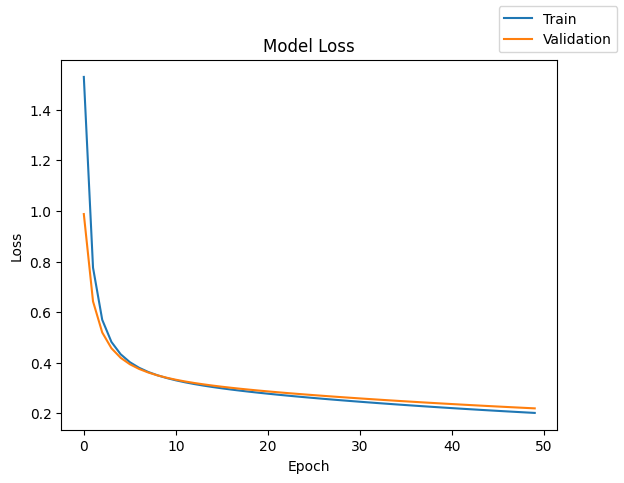

In [ ]:
plot(history,'loss')

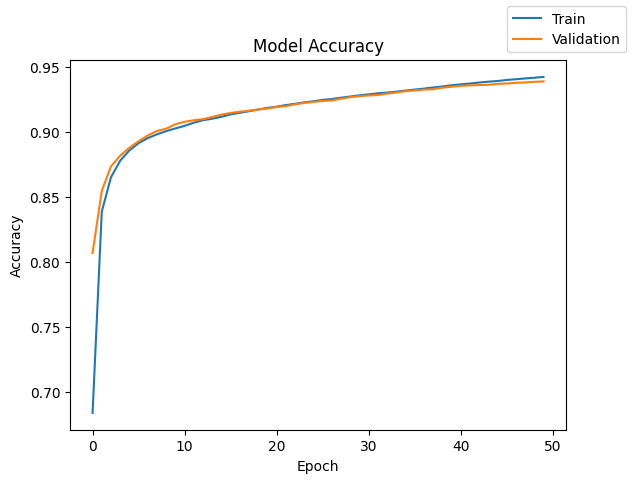

In [ ]:
plot(history,'accuracy')

In [ ]:
results.loc[7] = [1,128,'sigmoid',50,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

In [ ]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,train loss,validation loss,train accuracy,validation accuracy,time (secs)
0,0,-,-,10,50000,2.255868,2.238811,0.15270,0.1628,11.62
1,0,-,-,50,50000,1.927448,1.924149,0.43060,0.4332,26.04
2,0,-,-,10,32,0.327848,0.336322,0.90828,0.9071,59.80
3,0,-,-,50,32,0.272220,0.293814,0.92392,0.9186,258.24
4,0,-,-,50,64,0.290571,0.307456,0.91856,0.9144,171.80
5,1,64,sigmoid,50,50000,2.268767,2.266936,0.14812,0.1541,38.21
6,1,64,sigmoid,50,32,0.193652,0.211530,0.94558,0.9413,382.68
7,1,128,sigmoid,50,32,0.201664,0.219673,0.94258,0.9391,350.55


- Adding more neurons to the hidden layer hasn't help much
    - This is an observation for this dataset, might not be true for others


Another lever for us to change is the activation function for the hidden layer. Let's experiment with different activation functions.

###Model 8

In [ ]:
#clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(128,activation='tanh',input_dim = x_train.shape[1]))
model.add(Dense(num_classes, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = 32
epochs = 50
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [ ]:
start = time.time()
history = model.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8313 - loss: 0.6618 - val_accuracy: 0.8868 - val_loss: 0.4197
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8966 - loss: 0.3727 - val_accuracy: 0.9015 - val_loss: 0.3532
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9071 - loss: 0.3280 - val_accuracy: 0.9084 - val_loss: 0.3238
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9137 - loss: 0.3033 - val_accuracy: 0.9139 - val_loss: 0.3046
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9187 - loss: 0.2852 - val_accuracy: 0.9184 - val_loss: 0.2898
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9225 - loss: 0.2703 - val_accuracy: 0.9221 - val_loss: 0.2770
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9270 - loss: 0.2570 - val_accuracy: 0.9250 - val_loss: 0.2656
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9303 - loss: 0.2448 

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  364.695928812027


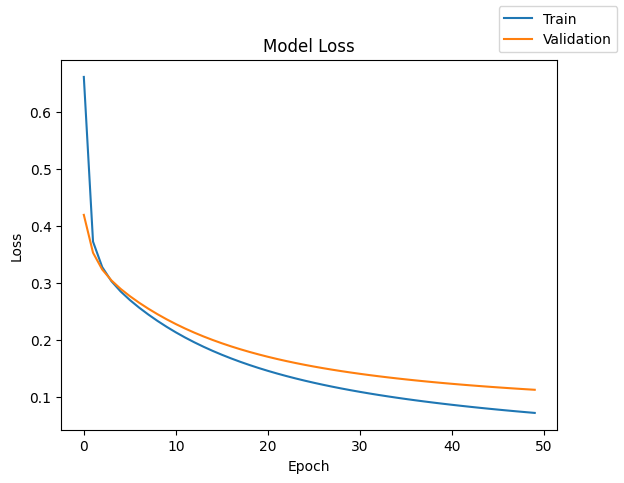

In [ ]:
plot(history,'loss')

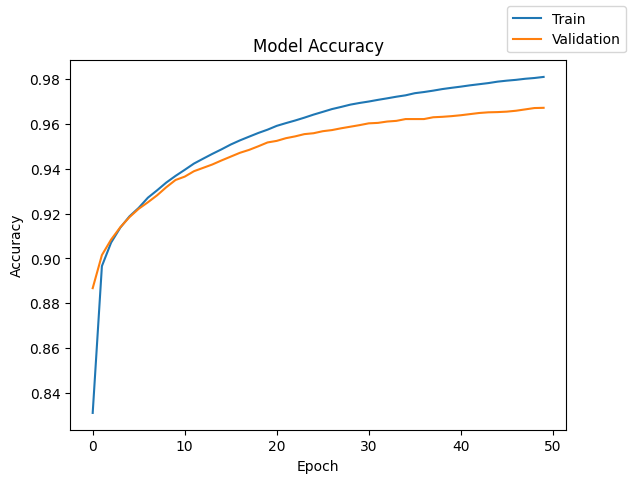

In [ ]:
plot(history,'accuracy')

In [ ]:
results.loc[8] = [1,128,'tanh',50,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

In [ ]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,train loss,validation loss,train accuracy,validation accuracy,time (secs)
0,0,-,-,10,50000,2.255868,2.238811,0.15270,0.1628,11.62
1,0,-,-,50,50000,1.927448,1.924149,0.43060,0.4332,26.04
2,0,-,-,10,32,0.327848,0.336322,0.90828,0.9071,59.80
3,0,-,-,50,32,0.272220,0.293814,0.92392,0.9186,258.24
4,0,-,-,50,64,0.290571,0.307456,0.91856,0.9144,171.80
5,1,64,sigmoid,50,50000,2.268767,2.266936,0.14812,0.1541,38.21
6,1,64,sigmoid,50,32,0.193652,0.211530,0.94558,0.9413,382.68
7,1,128,sigmoid,50,32,0.201664,0.219673,0.94258,0.9391,350.55
8,1,128,tanh,50,32,0.072019,0.112645,0.98074,0.9670,364.70


- With **tanh** as the activation function, we got a 4% improvement with the same time spent.

- Hence, it seems that the choice of activation function matters.

###Model 9

In [ ]:
#clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(128,activation='relu',input_dim = x_train.shape[1]))
model.add(Dense(num_classes, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = 32
epochs = 50
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [ ]:
start = time.time()
history = model.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8169 - loss: 0.7343 - val_accuracy: 0.8866 - val_loss: 0.4117
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9007 - loss: 0.3589 - val_accuracy: 0.9059 - val_loss: 0.3339
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9133 - loss: 0.3069 - val_accuracy: 0.9165 - val_loss: 0.2987
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9227 - loss: 0.2768 - val_accuracy: 0.9241 - val_loss: 0.2746
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9286 - loss: 0.2539 - val_accuracy: 0.9305 - val_loss: 0.2558
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9340 - loss: 0.2353 - val_accuracy: 0.9336 - val_loss: 0.2401
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9388 - loss: 0.2194 - val_accuracy: 0.9383 - val_loss: 0.2269
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9423 - loss: 0.2056 - 

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  346.7853624820709


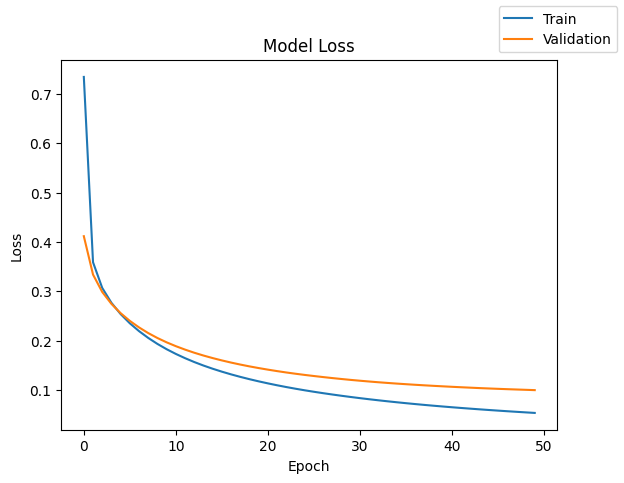

In [ ]:
plot(history,'loss')

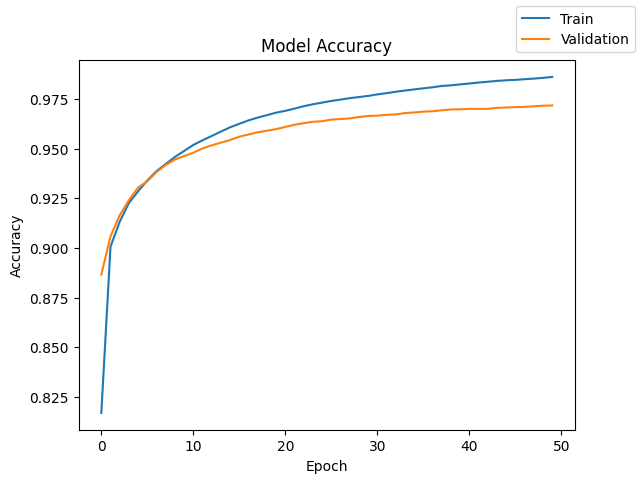

In [ ]:
plot(history,'accuracy')

In [ ]:
results.loc[9] = [1,128,'relu',50,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

In [ ]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,train loss,validation loss,train accuracy,validation accuracy,time (secs)
0,0,-,-,10,50000,2.255868,2.238811,0.15270,0.1628,11.62
1,0,-,-,50,50000,1.927448,1.924149,0.43060,0.4332,26.04
2,0,-,-,10,32,0.327848,0.336322,0.90828,0.9071,59.80
3,0,-,-,50,32,0.272220,0.293814,0.92392,0.9186,258.24
4,0,-,-,50,64,0.290571,0.307456,0.91856,0.9144,171.80
5,1,64,sigmoid,50,50000,2.268767,2.266936,0.14812,0.1541,38.21
6,1,64,sigmoid,50,32,0.193652,0.211530,0.94558,0.9413,382.68
7,1,128,sigmoid,50,32,0.201664,0.219673,0.94258,0.9391,350.55
8,1,128,tanh,50,32,0.072019,0.112645,0.98074,0.9670,364.70
9,1,128,relu,50,32,0.053729,0.099890,0.98620,0.9718,346.79


- With **relu** as the activation function, the performance improved slightly (~0.6%)

- Experimenting with different activation functions has helped

- This shows that activation functions is indeed a lever that one can change to try and improve  the overall model performance.
    - In our case, out of tanh, relu, and sigmoid, tanh and relu perform better than sigmoid

Now, let's try adding one more hidden layer to our neural network. We'll choose relu and tanh as the activation functions for it.

###Model 10

In [ ]:
#clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(128,activation='relu',input_dim = x_train.shape[1]))
model.add(Dense(64,activation='tanh'))
model.add(Dense(num_classes, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = 32
epochs = 50
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [ ]:
start = time.time()
history = model.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8269 - loss: 0.6874 - val_accuracy: 0.9010 - val_loss: 0.3674
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9130 - loss: 0.3142 - val_accuracy: 0.9208 - val_loss: 0.2829
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9277 - loss: 0.2553 - val_accuracy: 0.9314 - val_loss: 0.2437
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9366 - loss: 0.2211 - val_accuracy: 0.9393 - val_loss: 0.2181
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9436 - loss: 0.1966 - val_accuracy: 0.9436 - val_loss: 0.1991
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9491 - loss: 0.1775 - val_accuracy: 0.9466 - val_loss: 0.1843
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9534 - loss: 0.1618 - val_accuracy: 0.9503 - val_loss: 0.1722
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9574 - loss: 0.1485 - 

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  485.02507281303406


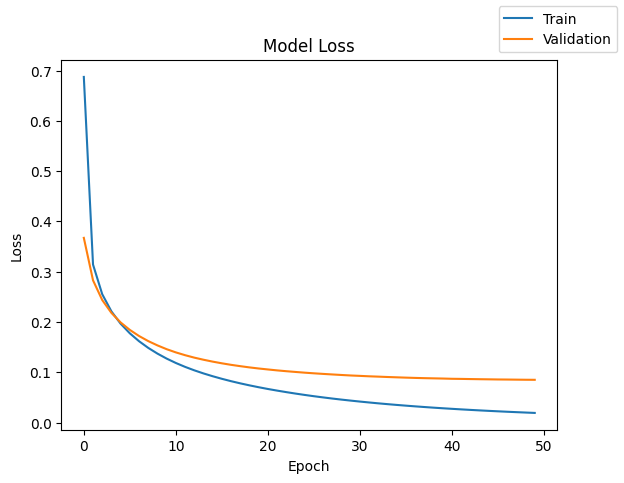

In [ ]:
plot(history,'loss')

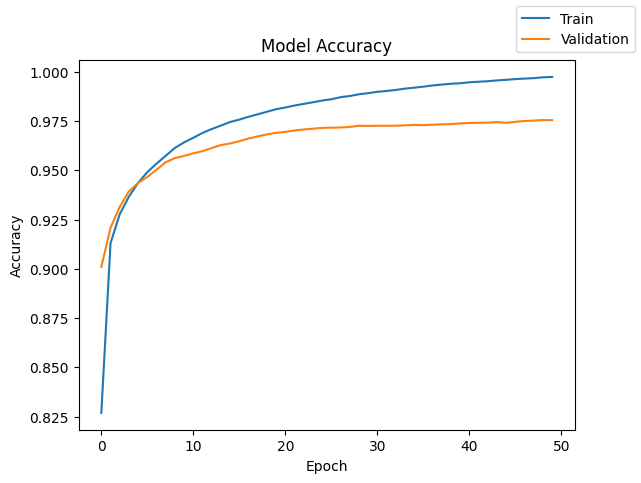

In [ ]:
plot(history,'accuracy')

In [ ]:
results.loc[10] = [2,[128,64],['relu','tanh'],50,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

In [ ]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,train loss,validation loss,train accuracy,validation accuracy,time (secs)
0,0,-,-,10,50000,2.255868,2.238811,0.15270,0.1628,11.62
1,0,-,-,50,50000,1.927448,1.924149,0.43060,0.4332,26.04
2,0,-,-,10,32,0.327848,0.336322,0.90828,0.9071,59.80
3,0,-,-,50,32,0.272220,0.293814,0.92392,0.9186,258.24
4,0,-,-,50,64,0.290571,0.307456,0.91856,0.9144,171.80
5,1,64,sigmoid,50,50000,2.268767,2.266936,0.14812,0.1541,38.21
6,1,64,sigmoid,50,32,0.193652,0.211530,0.94558,0.9413,382.68
7,1,128,sigmoid,50,32,0.201664,0.219673,0.94258,0.9391,350.55
8,1,128,tanh,50,32,0.072019,0.112645,0.98074,0.9670,364.70
9,1,128,relu,50,32,0.053729,0.099890,0.98620,0.9718,346.79


- Adding another layer with the best activation has slightly improved (~1%) the accuracy of the model.

- This increase is not only due to the addition of a new hidden layer but collectively depends on a set of carefully chosen hyperparameters (batch size, hidden layer activation, # hidden layers, # neurons in the hidden layer).

- The order of the activations of the hidden layers might matter.
- We have tried using relu activation for first hidden layer and tanh activation for the second hidden layer
- Let's try reversing the order

In [ ]:

from google.colab import drive
import os
drive.mount('/content/drive')

# Define the save directory and filename
save_dir = '/content/drive/MyDrive/rvs_genai_course/models'
model_name = 'minst_model_10'
save_path = os.path.join(save_dir, model_name + '.keras')

# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Save the trained Model 10
model.save(save_path)

print(f"Model 10 saved successfully to {save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model 10 saved successfully to /content/drive/MyDrive/rvs_genai_course/models/minst_model_10.keras


###Model 11

In [ ]:
#clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(128,activation='tanh',input_dim = x_train.shape[1]))
model.add(Dense(64,activation='relu'))
model.add(Dense(num_classes, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = 32
epochs = 50
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [ ]:
start = time.time()
history = model.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8268 - loss: 0.6736 - val_accuracy: 0.8938 - val_loss: 0.3735
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9068 - loss: 0.3233 - val_accuracy: 0.9131 - val_loss: 0.3002
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9199 - loss: 0.2723 - val_accuracy: 0.9227 - val_loss: 0.2647
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9300 - loss: 0.2411 - val_accuracy: 0.9300 - val_loss: 0.2402
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9373 - loss: 0.2176 - val_accuracy: 0.9365 - val_loss: 0.2213
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9436 - loss: 0.1986 - val_accuracy: 0.9406 - val_loss: 0.2063
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9474 - loss: 0.1826 - val_accuracy: 0.9456 - val_loss: 0.1935
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9514 - loss: 0.1689 - 

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  339.6103732585907


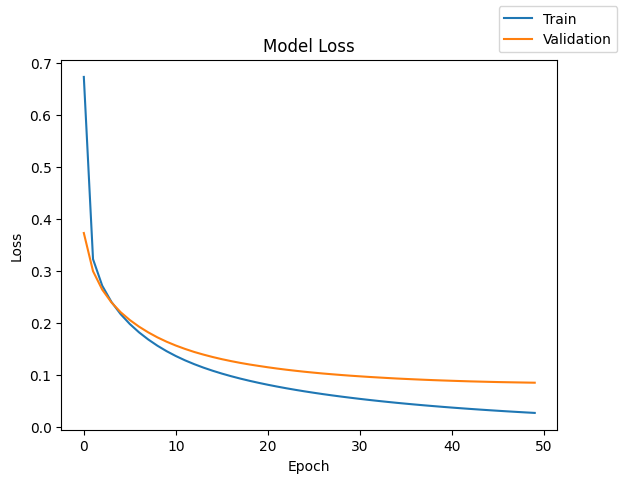

In [ ]:
plot(history,'loss')

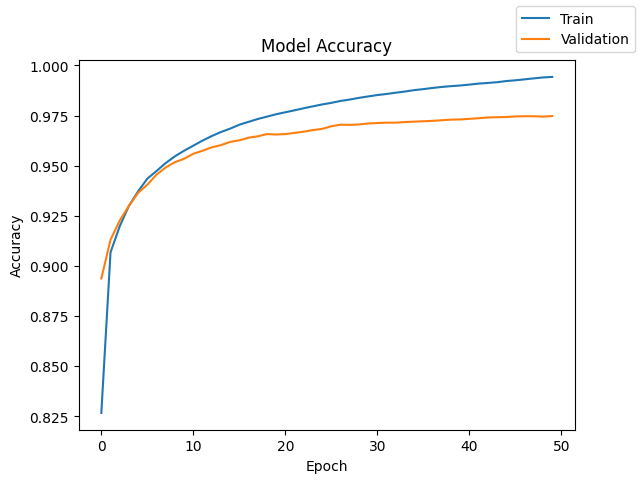

In [ ]:
plot(history,'accuracy')

In [ ]:
results.loc[11] = [2,[128,64],['tanh','relu'],50,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

In [ ]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,train loss,validation loss,train accuracy,validation accuracy,time (secs)
0,0,-,-,10,50000,2.255868,2.238811,0.15270,0.1628,11.62
1,0,-,-,50,50000,1.927448,1.924149,0.43060,0.4332,26.04
2,0,-,-,10,32,0.327848,0.336322,0.90828,0.9071,59.80
3,0,-,-,50,32,0.272220,0.293814,0.92392,0.9186,258.24
4,0,-,-,50,64,0.290571,0.307456,0.91856,0.9144,171.80
5,1,64,sigmoid,50,50000,2.268767,2.266936,0.14812,0.1541,38.21
6,1,64,sigmoid,50,32,0.193652,0.211530,0.94558,0.9413,382.68
7,1,128,sigmoid,50,32,0.201664,0.219673,0.94258,0.9391,350.55
8,1,128,tanh,50,32,0.072019,0.112645,0.98074,0.9670,364.70
9,1,128,relu,50,32,0.053729,0.099890,0.98620,0.9718,346.79


- The change in the order of activation has not yielded much different results

Let's try adding one more hidden layer with the best activation function (relu) we've seen.

###Model 12

In [ ]:
#clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(128,activation='relu',input_dim = x_train.shape[1]))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(num_classes, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = 32
epochs = 50
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [ ]:
start = time.time()
history = model.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7926 - loss: 0.7542 - val_accuracy: 0.8951 - val_loss: 0.3724
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9120 - loss: 0.3050 - val_accuracy: 0.9214 - val_loss: 0.2803
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9296 - loss: 0.2436 - val_accuracy: 0.9367 - val_loss: 0.2318
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9412 - loss: 0.2033 - val_accuracy: 0.9434 - val_loss: 0.2005
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9500 - loss: 0.1743 - val_accuracy: 0.9491 - val_loss: 0.1797
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9559 - loss: 0.1524 - val_accuracy: 0.9528 - val_loss: 0.1648
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9609 - loss: 0.1351 - val_accuracy: 0.9548 - val_loss: 0.1531
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9650 - loss: 0.1208 

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  377.49256324768066


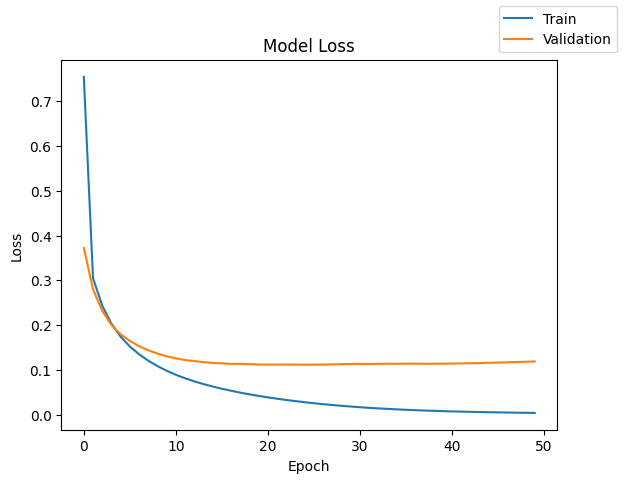

In [ ]:
plot(history,'loss')

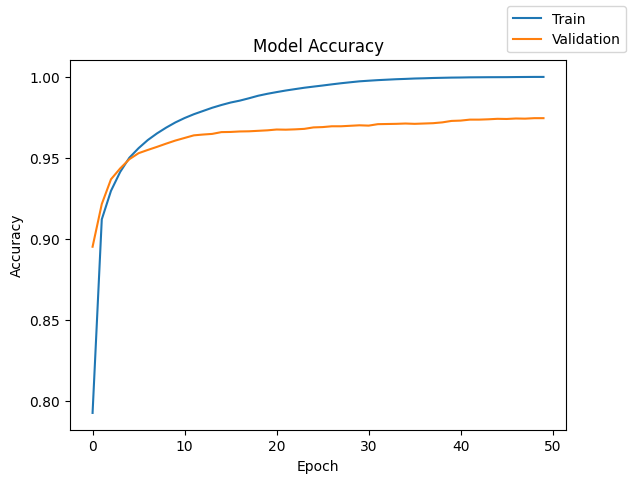

In [ ]:
plot(history,'accuracy')

In [ ]:
results.loc[12] = [3,[128,64,32],['relu','relu','relu'],50,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

In [ ]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,train loss,validation loss,train accuracy,validation accuracy,time (secs)
0,0,-,-,10,50000,2.255868,2.238811,0.15270,0.1628,11.62
1,0,-,-,50,50000,1.927448,1.924149,0.43060,0.4332,26.04
2,0,-,-,10,32,0.327848,0.336322,0.90828,0.9071,59.80
3,0,-,-,50,32,0.272220,0.293814,0.92392,0.9186,258.24
4,0,-,-,50,64,0.290571,0.307456,0.91856,0.9144,171.80
5,1,64,sigmoid,50,50000,2.268767,2.266936,0.14812,0.1541,38.21
6,1,64,sigmoid,50,32,0.193652,0.211530,0.94558,0.9413,382.68
7,1,128,sigmoid,50,32,0.201664,0.219673,0.94258,0.9391,350.55
8,1,128,tanh,50,32,0.072019,0.112645,0.98074,0.9670,364.70
9,1,128,relu,50,32,0.053729,0.099890,0.98620,0.9718,346.79


- The model's performance improved slightly (~0.5%)

Let's increase the number of epochs further to see what happens.

###Model 13


<center>
  <img src="https://drive.google.com/uc?export=view&id=1Eq6-yDVtfqpLoaiwr4niIYOq490kjkaS" alt="Description">
</center>

In [ ]:
#clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(128,activation='relu',input_dim = x_train.shape[1]))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(num_classes, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = 32
epochs = 100
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [ ]:
start = time.time()
history = model.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7942 - loss: 0.7175 - val_accuracy: 0.8989 - val_loss: 0.3519
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9153 - loss: 0.2908 - val_accuracy: 0.9259 - val_loss: 0.2639
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9334 - loss: 0.2277 - val_accuracy: 0.9381 - val_loss: 0.2184
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9456 - loss: 0.1882 - val_accuracy: 0.9452 - val_loss: 0.1888
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9536 - loss: 0.1604 - val_accuracy: 0.9506 - val_loss: 0.1702
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9590 - loss: 0.1398 - val_accuracy: 0.9546 - val_loss: 0.1571
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9642 - loss: 0.1238 - val_accuracy: 0.9586 - val_loss: 0.1465
Epoch 8/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9683 - loss: 

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  702.46915102005


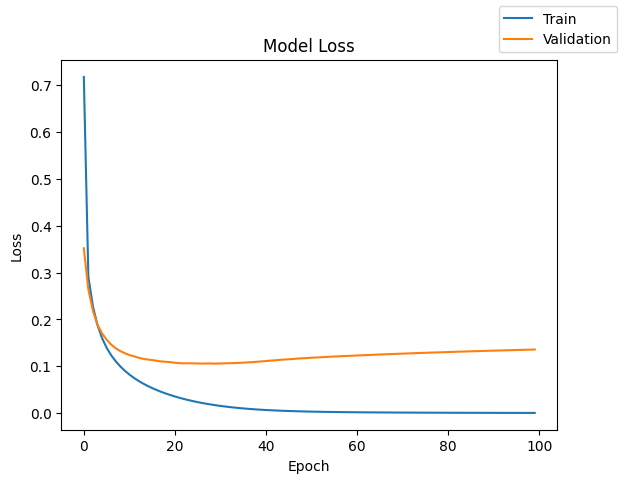

In [ ]:
plot(history,'loss')

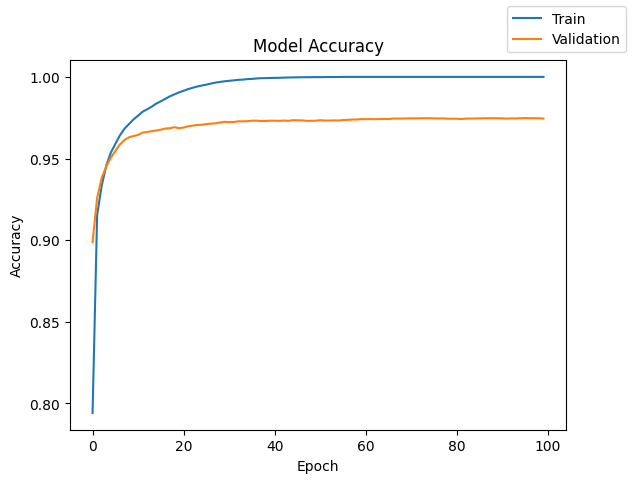

In [ ]:
plot(history,'accuracy')

In [ ]:
results.loc[13] = [3,[128,64,32],['relu','relu','relu'],100,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

In [ ]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,train loss,validation loss,train accuracy,validation accuracy,time (secs)
0,0,-,-,10,50000,2.255868,2.238811,0.15270,0.1628,11.62
1,0,-,-,50,50000,1.927448,1.924149,0.43060,0.4332,26.04
2,0,-,-,10,32,0.327848,0.336322,0.90828,0.9071,59.80
3,0,-,-,50,32,0.272220,0.293814,0.92392,0.9186,258.24
4,0,-,-,50,64,0.290571,0.307456,0.91856,0.9144,171.80
5,1,64,sigmoid,50,50000,2.268767,2.266936,0.14812,0.1541,38.21
6,1,64,sigmoid,50,32,0.193652,0.211530,0.94558,0.9413,382.68
7,1,128,sigmoid,50,32,0.201664,0.219673,0.94258,0.9391,350.55
8,1,128,tanh,50,32,0.072019,0.112645,0.98074,0.9670,364.70
9,1,128,relu,50,32,0.053729,0.099890,0.98620,0.9718,346.79


- The training accuracy has reached it's peak (100% accurate)

- The validation accuracy doesn't appear to have changed much in the last few models we built
    - The validation accuracy seems to be in the range [0.9700 - 0.9760] in the last few models

- The time taken for 100 epochs, though, is almost double than before, which is expected.

## Conclusions

In [ ]:
print(results)

best_model_accuracy = results.loc[results['validation accuracy'].idxmax()]
best_model_loss = results.loc[results['validation loss'].idxmin()]

print('\nBest Model based on Validation Accuracy:')
print(best_model_accuracy)

print('\nBest Model based on Validation Loss:')
print(best_model_loss)

    # hidden layers # neurons - hidden layer  \
0                 0                        -   
1                 0                        -   
2                 0                        -   
3                 0                        -   
4                 0                        -   
5                 1                       64   
6                 1                       64   
7                 1                      128   
8                 1                      128   
9                 1                      128   
10                2                [128, 64]   
11                2                [128, 64]   
12                3            [128, 64, 32]   
13                3            [128, 64, 32]   

   activation function - hidden layer  # epochs  batch size  train loss  \
0                                   -        10       50000    2.255868   
1                                   -        50       50000    1.927448   
2                                   -        10       

Let's add the 'no. of batches' and 'no. of parameters changed' columns to the results DataFrame for further analysis.

In [ ]:
def calculate_total_trainable_parameters(num_hidden_layers, hidden_neurons_spec, input_dim, output_dim):
    """
    Calculates the total number of trainable parameters for a given neural network architecture.

    Args:
        num_hidden_layers (int): Number of hidden layers.
        hidden_neurons_spec: Specification for hidden layer neurons.
                             Can be an int (for 1 hidden layer), a list of ints, or a string '-' (for 0 hidden layers).
        input_dim (int): Dimension of the input layer (e.g., 784 for MNIST flattened images).
        output_dim (int): Dimension of the output layer (e.g., 10 for 10 digit classes).

    Returns:
        int: Total number of trainable parameters.
    """
    total_params = 0
    current_input_dim = input_dim

    if num_hidden_layers == 0:
        # No hidden layers, directly connected input to output
        total_params = (current_input_dim * output_dim) + output_dim
    else:
        # Ensure hidden_neurons_list is a list of integers for iteration
        if isinstance(hidden_neurons_spec, int):
            hidden_neurons_list = [hidden_neurons_spec]
        elif isinstance(hidden_neurons_spec, list):
            hidden_neurons_list = hidden_neurons_spec
        else:
            # Fallback for unexpected types, though should be covered by num_hidden_layers == 0
            hidden_neurons_list = []

        for layer_output_dim in hidden_neurons_list:
            total_params += (current_input_dim * layer_output_dim) + layer_output_dim
            current_input_dim = layer_output_dim
        # Add output layer parameters after all hidden layers
        total_params += (current_input_dim * output_dim) + output_dim

    return total_params

# Assuming x_train.shape[0], x_train.shape[1], and num_classes are available from previous cells.
# x_train.shape[0] = 50000 (number of training samples)
# x_train.shape[1] = 784 (input dimension for flattened images)
# num_classes = 10 (output dimension)

new_batches = []
new_parameters = []

for index, row in results.iterrows():
    # Calculate 'no. of batches' (total updates in terms of batches)
    batch_size_val = row['batch size']
    epochs_val = row['# epochs']

    # x_train.shape[0] is the total number of training samples
    # The number of batches per epoch is x_train.shape[0] / batch_size_val
    # Total batches over all epochs = (x_train.shape[0] / batch_size_val) * epochs_val
    if batch_size_val > 0:
        total_batches = (x_train.shape[0] / batch_size_val) * epochs_val
    else:
        total_batches = 0  # Handle cases where batch_size might be zero or problematic
    new_batches.append(total_batches)

    # Calculate 'no. of parameters changed' (total trainable parameters for the architecture)
    params = calculate_total_trainable_parameters(
        row['# hidden layers'],
        row['# neurons - hidden layer'],
        x_train.shape[1],
        num_classes
    )
    new_parameters.append(params)

# Add the new columns to the results DataFrame
results['no. of batches'] = new_batches
results['no. of parameters changed'] = new_parameters

display(results)

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,train loss,validation loss,train accuracy,validation accuracy,time (secs),no. of batches,no. of parameters changed
0,0,-,-,10,50000,2.255868,2.238811,0.15270,0.1628,11.62,10.0,7850
1,0,-,-,50,50000,1.927448,1.924149,0.43060,0.4332,26.04,50.0,7850
2,0,-,-,10,32,0.327848,0.336322,0.90828,0.9071,59.80,15625.0,7850
3,0,-,-,50,32,0.272220,0.293814,0.92392,0.9186,258.24,78125.0,7850
4,0,-,-,50,64,0.290571,0.307456,0.91856,0.9144,171.80,39062.5,7850
5,1,64,sigmoid,50,50000,2.268767,2.266936,0.14812,0.1541,38.21,50.0,50890
6,1,64,sigmoid,50,32,0.193652,0.211530,0.94558,0.9413,382.68,78125.0,50890
7,1,128,sigmoid,50,32,0.201664,0.219673,0.94258,0.9391,350.55,78125.0,101770
8,1,128,tanh,50,32,0.072019,0.112645,0.98074,0.9670,364.70,78125.0,101770
9,1,128,relu,50,32,0.053729,0.099890,0.98620,0.9718,346.79,78125.0,101770


Based on the validation metrics, Model 10 and Model 11 show very similar and good performance. However, if we consider both validation accuracy and validation loss, Model 10 (index 10 in the results DataFrame) achieved slightly better validation accuracy (0.9754) and a slightly lower validation loss (0.085057) compared to other models.

This model uses 2 hidden layers with [128, 64] neurons and ['relu', 'tanh'] activation functions, trained for 50 epochs with a batch size of 32.

### The Winner: Model 10

**Architecture:**
*   2 Hidden Layers `[128, 64]` with `['relu', 'tanh']` activations.

**Performance:**
*   Validation Accuracy: `97.54%` (The highest across all configurations).
*   Validation Loss: `0.085057` (The lowest validation error in the entire run).
*   Training Time: `297.25` seconds.

**Short Reasoning:**
*   **Generalization over Overfitting:** While deeper architectures like Model 12 and Model 13 achieved near-perfect and perfect training accuracies (`99.98%` and `100.00%`), their validation losses began to climb significantly (`0.118971` and `0.135910`). This indicates clear overfitting.
*   **Optimal Balance:** Model 10 hits the sweet spot. It achieves the lowest validation error and the highest validation accuracy, proving it handles unseen data better than any other model in your experiment.

**Honorable Mention (For Efficiency): Model 9**
If you need a faster, lighter model, Model 9 (1 hidden layer, 128 neurons, relu) achieves a highly competitive `97.18%` validation accuracy in `279.62` seconds, utilizing only a single hidden layer.

In [ ]:
# import os
# import tensorflow as tf
# from tensorflow import keras
# from keras.models import Sequential
# from keras.layers import Dense

# # Clear the current Keras session to ensure a clean slate for Model 10
# tf.keras.backend.clear_session()

# # Recreate Model 10 architecture as per the notebook's analysis
# model_10 = Sequential()
# model_10.add(Dense(128, activation='relu', input_dim=x_train.shape[1]))
# model_10.add(Dense(64, activation='tanh'))
# model_10.add(Dense(num_classes, activation='softmax'))

# # Compile Model 10 with the specified parameters
# model_10.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

# # Define training parameters for Model 10
# batch_size_10 = 32
# epochs_10 = 50

# # Train Model 10
# print("Training Model 10 to save it...")
# history_10 = model_10.fit(
#     x_train, y_train,
#     validation_data=(x_val, y_val),
#     batch_size=batch_size_10,
#     epochs=epochs_10,
#     verbose=0 # Suppress verbose output during training for cleaner execution
# )
# print("Model 10 training complete.")



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Model 10 to save it...
Model 10 training complete.


# Make Prediction with existing data

In [ ]:
predictions = model.predict(x_test)
print("Predictions for the first 5 test samples:")
print(predictions[:5])


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predictions for the first 5 test samples:
[[3.20335291e-14 3.99421425e-12 9.14718301e-10 1.88155241e-07 6.24613412e-14 7.13710639e-14 1.15667646e-20 9.99999702e-01 8.32970845e-12 4.34759384e-09]
 [4.89219776e-13 3.88038091e-09 9.99999940e-01 3.93034716e-09 6.34730169e-23 1.69960723e-19 4.51866582e-15 9.21450403e-16 1.79233622e-13 4.22464696e-25]
 [9.03311627e-12 9.99998748e-01 1.48815943e-07 6.45533557e-11 9.29229941e-07 8.31296837e-13 1.65832137e-09 8.76639490e-08 1.48179149e-08 7.03728005e-12]
 [9.99999940e-01 2.12486905e-14 1.20559962e-08 7.17313954e-17 2.01566872e-14 1.01126999e-16 2.80364816e-12 7.00095364e-12 5.03039860e-19 6.13730637e-12]
 [2.57112054e-10 2.97991937e-10 4.58122762e-10 3.31547432e-14 9.99976575e-01 5.60025203e-16 3.28192917e-09 2.52094576e-08 4.90788632e-10 2.33847622e-05]]


In [ ]:
sample_index = 0
sample_data = x_test[sample_index].reshape(1, 784)

print(sample_data.reshape(28,28))

[[0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.        

In [ ]:
sample_index = 0
sample_data = x_test[sample_index].reshape(1, 784)

# Make a prediction
prediction = model.predict(sample_data)

# Get the predicted digit (the one with the highest probability)
predicted_digit = np.argmax(prediction)

print(f"The predicted digit for sample {sample_index} is: {predicted_digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
The predicted digit for sample 0 is: 7


# New Prediction (Unseen Data - Handwritten num)

In [ ]:
try:
    from PIL import Image

except ImportError:
    !pip install Pillow -q --user --no-warn-script-location
    from PIL import Image

# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# --- User input required ---
# Replace 'path/to/your/image.jpg' with the actual path to your image file in Google Drive.
# For example: '/content/drive/MyDrive/my_digit.png'
image_path = '/content/drive/MyDrive/rvs_genai_course/python_notebook/asserts/num_2.png' # <<< CHANGE THIS TO YOUR IMAGE PATH

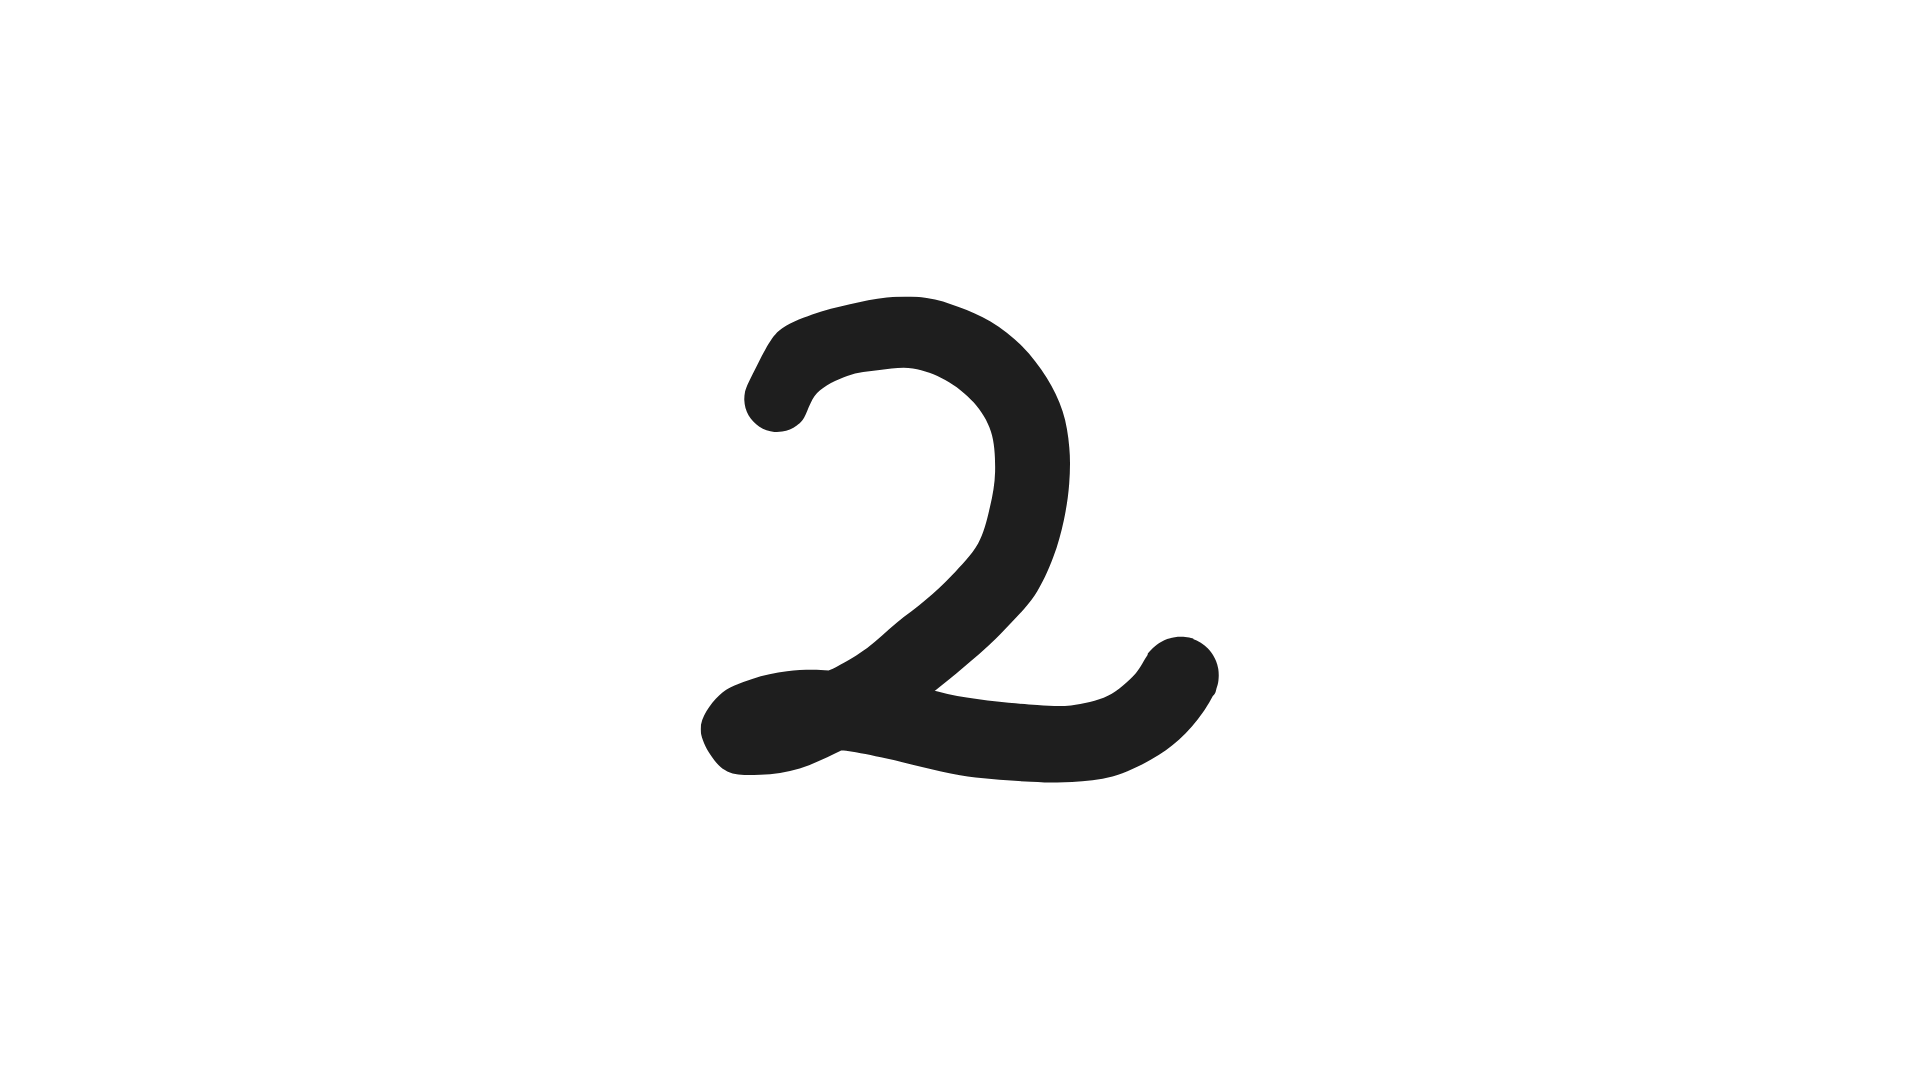

In [ ]:
 # Load the image
img = Image.open(image_path)

display(img)

In [ ]:
# Convert to grayscale (monochrome) and resize to 28x28 pixels
# Image.L for monochrome (8-bit pixels, black and white)
img_gray = img.convert('L').resize((28, 28))
display(img_gray)

In [ ]:
# Convert image to numpy array
img_array = np.array(img_gray)
print(img_array)

[[255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 255 255 255 255 255 213 198 255 255 255 255 255 255 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 255 255 255 255 143  22  15 134 255 255 255 255 25

In [ ]:
# Invert the pixel values (0 becomes 255, 255 becomes 0)
img_inverted = 255 - img_array
print(img_inverted)

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  42  57   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 112 233 240 121   0   0   0   0   

In [ ]:
# Normalize the pixel values to 0-1
# MNIST images are 0-255, so we divide by 255.0 to get floats between 0 and 1.
img_normalized = img_inverted.astype('float32') / 255.0

# Reshape the image for prediction (1 sample, 784 pixels flattened)
# The models in this notebook expect a flattened input of shape (1, 784)
input_image_for_prediction = img_normalized.reshape(1, 28*28)

print("Image loaded and preprocessed successfully!")
print("Shape of processed image for prediction:", input_image_for_prediction.shape)
print("First 10 pixel values (normalized):", input_image_for_prediction[0, :10])

# Now you can use input_image_for_prediction with your model

# For example:
prediction = model.predict(input_image_for_prediction)
print("Prediction:", prediction)
predicted_digit = np.argmax(prediction)
print(f"Predicted digit: {predicted_digit}")


Image loaded and preprocessed successfully!
Shape of processed image for prediction: (1, 784)
First 10 pixel values (normalized): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Prediction: [[1.0234036e-07 2.1266824e-02 9.7264206e-01 1.0339980e-03 3.5279305e-07 8.3705923e-04 4.7560118e-04 3.3559829e-03 3.8795359e-04 7.8888829e-10]]
Predicted digit: 2


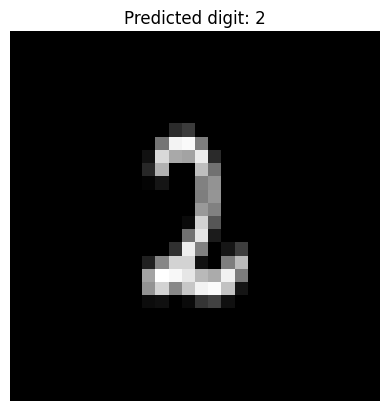

In [ ]:
plt.imshow(img_inverted, cmap='gray')
plt.title(f"Predicted digit: {predicted_digit}")
plt.axis('off')
plt.show()